In [1]:
import numpy as np
from nbodykit.lab import ArrayMesh

from tqdm import tqdm
js_min = 663
js_max = 664
js_all = np.arange(js_min, js_max).astype(int)
for sim_id in tqdm(js_all):
    nfiles = 4
    try:
        # path = '/mnt/ceph/users/cmodi/fastpm-shivam/fid_3Gpc/' + str(sim_id) + '/'
        path = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/' + str(sim_id) + '/ICs/'        
        idx = []
        amp, phase = [], []
        print("\nConvert for path: ", path)

        for i in range(nfiles):
            # read a particular coordinate file
            f_in = path + 'Coordinates_ptype_1.%d'%i
            f = open(f_in, 'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles	
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            coordinates = np.fromfile(f, dtype=np.int64, count=-1)
            kx = (coordinates//(Nmesh//2 + 1))//Nmesh
            ky = (coordinates//(Nmesh//2 + 1))%Nmesh
            kz = (coordinates%(Nmesh//2 + 1))%Nmesh
            kk = np.array([kx, ky, kz]).T
            idx.append(kk)

            f_in = path + 'Amplitudes_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles	
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            aa = np.fromfile(f, dtype=np.float32, count=-1)
            amp.append(aa)

            f_in = path + 'Phases_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles	
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            phase.append(np.fromfile(f, dtype=np.float32, count=-1))
    except Exception as e:
        print("Error for sim_id: ", sim_id, " with error: ", e)
        pass

    print("Concatenated files")
    idx = np.concatenate(idx)
    amp = np.concatenate(amp)
    phase = np.concatenate(phase)

    val = amp*np.exp(1j*phase)
    cmesh = val.reshape(Nmesh, Nmesh, kz.max()+1)

    bs=3000
    mesh = np.fft.irfftn(cmesh, norm='ortho') * Nmesh**1.5
    print("check mesh std: ", mesh.std())

    print("Creating BigFile")
    amesh = ArrayMesh(mesh, BoxSize=[bs, bs, bs])
    #plt.imshow(mesh.sum(axis=0))
    amesh.save(path + 'linear', dataset='LinearDensityK', mode='complex') 


# bs=1000
# mesh = np.fft.irfftn(cmesh, norm='ortho') * Nmesh**1.5
# print("check mesh std: ", mesh.std())

# print("Creating BigFile")
# amesh = ArrayMesh(mesh, BoxSize=[bs, bs, bs])
# #plt.imshow(mesh.sum(axis=0))
# amesh.save(path + 'linear', dataset='LinearDensityK', mode='complex') 




  0%|          | 0/1 [00:00<?, ?it/s]


Convert for path:  /mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/663/ICs/
Concatenated files
check mesh std:  0.026226432277070142
Creating BigFile


100%|██████████| 1/1 [13:07<00:00, 787.57s/it]


In [ ]:
# # read bigfile and create the correct arrays
# import sys, os
# import numpy as np
# from tqdm import tqdm
# import nbodykit.lab as nb
# from nbodykit.source.catalog.file import BigFileCatalog
# import h5py as h5

# a_vals = ['0.3333', '0.5000', '0.6667']
# z_vals = ['2', '1', '0.5']

# # a_vals = ['0.6667']
# # z_vals = ['0.5']

# sdir = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/'
# js_min = 663
# js_max = 664
# js_all = np.arange(js_min, js_max).astype(int)

# for js in tqdm(js_all):
#     sdir_js = sdir + '%d/'%js
#     print(sdir_js)
#     # os.makedirs(sdir_js, exist_ok=True)
#     for a, z in zip(a_vals, z_vals):
#         print("\nProcessing for a: ", a, " and z: ", z)
#         df = nb.BigFileCatalog('/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/' + str(js) + '/ICs/fastpm_B2_' + a, dataset='1')
#         # df_mesh = df.to_mesh(window='cic', Nmesh=ns_h, compensated=True, BoxSize=1000)
#         # df_mesh_np_B3 = df_mesh.preview()

#         # df.columns
#         pos = np.array(df['Position'], dtype=np.float32)
#         vel = np.array(df['Velocity'], dtype=np.float32)
#         # save in the hdf5 file
        
#         print("Saving in hdf5 file for z: ", z)
#         f = h5.File(sdir_js + 'SNAPSHOT_fastpm_B2_z' + z + '.hdf5', 'w')
#         f.create_dataset('Position', data=pos)
#         f.create_dataset('Velocity', data=vel)
#         f.close()




  0%|          | 0/1 [00:00<?, ?it/s]/mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/663/

Processing for a:  0.3333  and z:  2


In [ ]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import h5py as h5
import os

a_vals = ['0.3333', '0.5000', '0.6667']
z_vals = ['2', '1', '0.5']

# a_vals = ['0.6667']
# z_vals = ['0.5']


sdir = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/'
js_min = 663
js_max = 664
js_all = np.arange(js_min, js_max).astype(int)

NFILES = 108
PARTICLES_PER_FILE = 33554432  # from header
N_TOTAL = NFILES * PARTICLES_PER_FILE  # 3,623,878,656

def read_raw_file(fpath, n_particles):
    """Read a raw bigfile binary chunk: n_particles × 3 float32."""
    return np.fromfile(fpath, dtype='<f4').reshape(n_particles, 3)

for js in tqdm(js_all):
    sdir_js = sdir + '%d/' % js
    for a, z in zip(a_vals, z_vals):
        print(f"\nProcessing a={a}, z={z}")
        
        base = sdir + f'{js}/ICs/fastpm_B2_{a}/1'
        pos_dir = base + '/Position'
        vel_dir = base + '/Velocity'
        out_path = sdir_js + f'SNAPSHOT_fastpm_B2_z{z}.hdf5'
        
        with h5.File(out_path, 'w') as f:
            # No compression = fastest possible writes
            ds_pos = f.create_dataset('Position', shape=(N_TOTAL, 3), dtype='float32')
            ds_vel = f.create_dataset('Velocity', shape=(N_TOTAL, 3), dtype='float32')
            
            # Use thread pool to overlap reads with writes
            # Read pos and vel for next file while writing current
            with ThreadPoolExecutor(max_workers=4) as pool:
                offset = 0
                for i in tqdm(range(NFILES), desc=f"z={z}"):
                    fname = f'{i:06X}'
                    n = PARTICLES_PER_FILE
                    
                    # Read pos and vel in parallel threads
                    fut_pos = pool.submit(read_raw_file, f'{pos_dir}/{fname}', n)
                    fut_vel = pool.submit(read_raw_file, f'{vel_dir}/{fname}', n)
                    
                    pos_data = fut_pos.result()
                    vel_data = fut_vel.result()
                    
                    # Write to HDF5
                    ds_pos[offset:offset+n] = pos_data
                    ds_vel[offset:offset+n] = vel_data
                    offset += n
        
        print(f"  Saved: {out_path} ({os.path.getsize(out_path)/1e9:.1f} GB)")




  0%|          | 0/1 [00:00<?, ?it/s]


Processing a=0.6667, z=0.5


100%|██████████| 1/1 [04:57<00:00, 297.60s/it]

  Saved: /mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/663/SNAPSHOT_fastpm_B2_z0.5.hdf5 (87.0 GB)


In [1]:
import h5py as h5
import numpy as np
df = h5.File('/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/663/SNAPSHOT_fastpm_B2_z0.5.hdf5', 'r')
pos = np.array(df['Position'], dtype=np.float32)
vel = np.array(df['Velocity'], dtype=np.float32)
print("Position shape: ", pos.shape)
print("Velocity shape: ", vel.shape)
df.close()


Position shape:  (3623878656, 3)
Velocity shape:  (3623878656, 3)


In [2]:
# np.amin(pos), np.amax(pos)



(5.424681e-09, 3000.0)

In [2]:
import MAS_library as MASL
import Pk_library as PKL

nax_h = 1536
BoxSize = 3000.0
MAS = 'CIC'
verbose = True

delta_mock = np.zeros((nax_h,nax_h,nax_h), dtype=np.float32)

# construct 3D density field
MASL.MA(pos, delta_mock, BoxSize, MAS, verbose=verbose)

# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta_mock /= np.mean(delta_mock, dtype=np.float64);  delta_mock -= 1.0





Using CIC mass assignment scheme
Time taken = 84.921 seconds



In [3]:
axis=0
threads=10
# compute power spectrum
Pk_mock = PKL.Pk(delta_mock, BoxSize, axis, MAS, threads, verbose)
k_mock_js       = Pk_mock.k3D
Pk0_mock_js     = Pk_mock.Pk[:,0] #monopole





Computing power spectrum of the field...
Time to complete loop = 116.97
Time taken = 141.49 seconds


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline



Text(0, 0.5, 'P(k) [(Mpc/h)^3]')

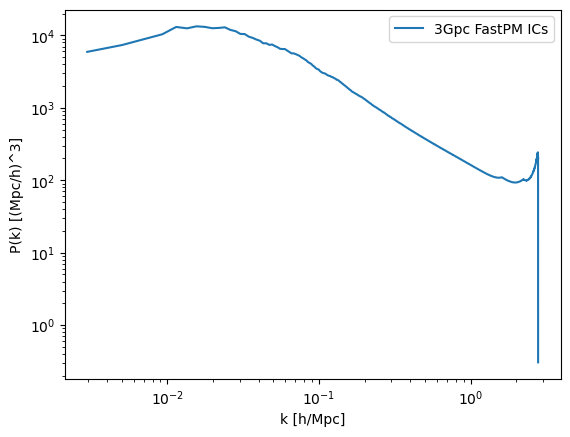

In [5]:
plt.figure()
plt.plot(k_mock_js, Pk0_mock_js, label='3Gpc FastPM ICs')
# plt.plot(k_quijote_js, Pk0_quijote_js, label='Quijote ICs')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')




In [6]:
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
root = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube/'
ji = 663
snapnum = 3
snapshot = '%s/%d/snapdir_%03d/snap_%03d'%(root,ji,snapnum,snapnum)
ptypes       = [1]
grid         = 512
BoxSize_q = 1000.0 #Mpc/h ; size of box
MAS = 'CIC'
posq = readgadget.read_block(snapshot, "POS ", ptypes)/1e3 #positions in Mpc/h
df_cic = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(np.float32(posq), df_cic, BoxSize_q, MAS, verbose=False)
df_quijote = df_cic/np.mean(df_cic, dtype=np.float64)-1.0

axis=0
threads=10
# compute power spectrum
Pk_quijote = PKL.Pk(df_quijote, BoxSize_q, axis, MAS, threads, verbose)
k_quijote_js       = Pk_quijote.k3D
Pk0_quijote_js     = Pk_quijote.Pk[:,0] #monopole







Computing power spectrum of the field...
Time to complete loop = 4.34
Time taken = 5.74 seconds


In [7]:
import matplotlib.pyplot as plt
%matplotlib inline


In [8]:
dfl = np.loadtxt('/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/663/ICs/powerspec_linear.txt')
dfl.shape


(768, 3)

Text(0, 0.5, 'P(k) [(Mpc/h)^3]')

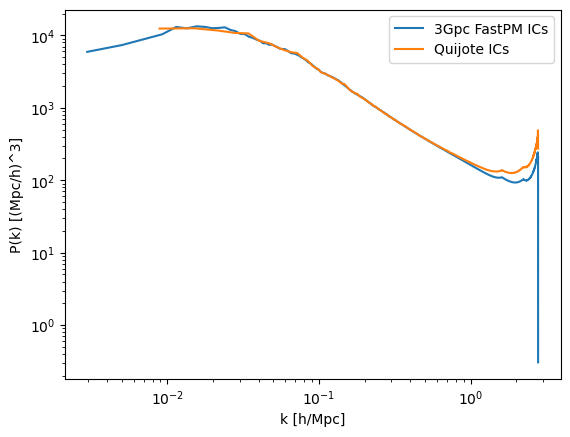

In [10]:
plt.figure()
plt.plot(k_mock_js, Pk0_mock_js, label='3Gpc FastPM ICs')
plt.plot(k_quijote_js, Pk0_quijote_js, label='Quijote ICs')
# plt.plot(dfl[:,0], dfl[:,1], label='Linear Theory')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')




In [5]:
import h5py as h5
import numpy as np
df = h5.File('/mnt/ceph/users/wcoulton/nbodysims/products/fiducial/100/halos/99/halos_99.638.h5', 'r')
print(df.keys())
# print(df['PID'][()])
pid = np.array(df['PID'])
print(pid[pid > -1])
df.close()




<KeysViewHDF5 ['A[x]', 'A[x](500c)', 'A[y]', 'A[y](500c)', 'A[z]', 'A[z](500c)', 'C[x]', 'C[y]', 'C[z]', 'DescID', 'Halfmass_Radius', 'ID', 'JX', 'JY', 'JZ', 'M200b', 'M200c', 'M2500c', 'M500c', 'M_pe_Behroozi', 'M_pe_Diemer', 'Mvir', 'Mvir_all', 'Np', 'PID', 'Rs', 'Rvir', 'Spin', 'T', 'VX', 'VY', 'VZ', 'Vmax', 'Voff', 'Vrms', 'X', 'Xoff', 'Y', 'Z', 'b_to_a', 'b_to_a(500c)', 'c_to_a', 'c_to_a(500c)', 'environ_5mpch_comov', 'environ_5mpch_phys', 'rs_klypin', 'spin_bullock']>
[40496099. 40496786. 40494515. 40494515. 40494515. 40494515. 40494514.
 40496828. 40496827. 40494114. 40498509. 40498508. 40496536. 40493415.
 40493213. 40491779. 40491774. 40491774. 40491774. 40491773. 40491774.
 40491774. 40491779. 40491781. 40495476. 40486753. 40486753. 40486748.
 40486753. 40486753. 40486753. 40486753. 40486753. 40486753. 40486754.
 40486753. 40486779. 40486753. 40486753. 40486762. 40490920. 40490920.
 40486753. 40486753. 40486753. 40486779. 40486779. 40486753. 40486765.
 40486754. 40492753. 404